In [8]:
import matplotlib.pylab as plt
import numpy as np
import json
import os
import datetime
from matplotlib import dates

In [9]:
dir="/Users/jracusin/GCN/gitrep/gcn-notebooks/archive.json/"

In [10]:
circ=[]
subhow0=[]
subwho0=[]
subwhen0=[]
evid0=[]
subject0=[]
bibcode0=[]

for (root, dirs, file) in os.walk(dir):
    for f in file:
        if '.json' in f:
            ff = open(dir+f)
            data = json.load(ff)
            circ.append(float(f.split('.json')[0]))
            subwho0.append(data["submitter"])
            subwhen0.append(datetime.datetime.fromtimestamp(int(data["createdOn"]) / 1000.0))#, tz=datetime.timezone.utc))
            if "submittedHow" in data:
                # print(data["submittedHow"])
                subhow0.append(data["submittedHow"])
            else:
                subhow0.append('email-legacy')
#                subwhen.append(datetime.utcfromtimestamp(int(data["createdOn"])).strftime('%Y-%m-%d %H:%M:%S'))
            if "eventId" in data:
                evid0.append(data["eventId"])
            else:
                evid0.append('None')
            if "subject" in data:
                subject0.append(data["subject"])
            else:
                subject0.append('None')
            if "bibcode" in data:
                bibcode0.append(data["bibcode"])
            else:
                bibcode0.append('None')

In [11]:
s=np.argsort(subwhen0)
circ=np.array(circ)
#circ = circ.astype(np.int64)
circ=circ[s]
# subhow0=np.array(subhow)
# subwho0=np.array(subwho)
# subwhen0=np.array(subwhen)
subhow=np.array(subhow0)[s]
subwho=np.array(subwho0)[s]
subwhen=np.array(subwhen0)[s]
evid=np.array(evid0)[s]
subject=np.array(subject0)[s]
bibcode=np.array(bibcode0)[s]

In [12]:
len(subhow0),len(subwho0),len(subwhen0),len(evid0),len(subject0),len(bibcode0)

(41645, 41645, 41645, 41645, 41645, 41645)

In [6]:
print(max(subwhen))

2025-08-03 15:17:03.799000


In [7]:
wemail=np.where(np.array(subhow) == 'email')[0]
wlegemail=np.where(np.array(subhow) == 'email-legacy')[0]
wweb=np.where(np.array(subhow) == 'web')[0]
print(len(wemail),len(wlegemail),len(wweb))

1660 35049 4390


In [8]:
print(subwhen)

[datetime.datetime(1997, 8, 13, 20, 0)
 datetime.datetime(1997, 9, 1, 20, 0)
 datetime.datetime(1997, 9, 11, 20, 0) ...
 datetime.datetime(2025, 8, 3, 1, 18, 45, 243000)
 datetime.datetime(2025, 8, 3, 8, 45, 12, 467000)
 datetime.datetime(2025, 8, 3, 15, 17, 3, 799000)]


2025


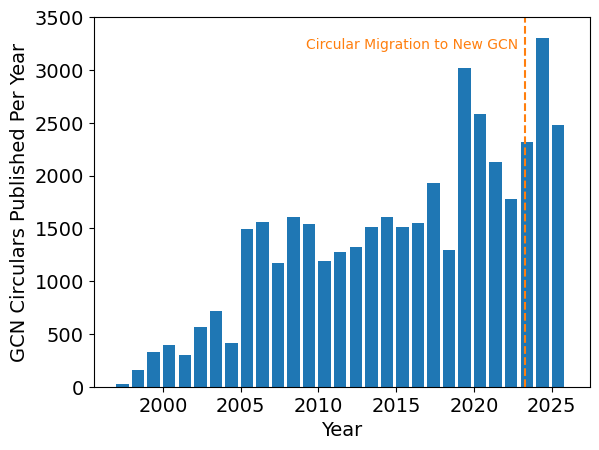

In [132]:
# year=[]
# nyear=[]
# for s in subwhen: 
#     year.append(s.year)
# year=np.array(year,dtype=int)
# bins=np.arange(np.min(year),np.max(year)+1,1)
# print(bins)
year = [date.year for date in subwhen]
print(max(year))
h=plt.hist(year,bins=np.arange(1997,2027),width=0.8)
plt.ylabel('GCN Circulars Published Per Year')
plt.xlabel('Year')
plt.plot([2023.3,2023.3],[0,3500],linestyle='--')
plt.annotate('Circular Migration to New GCN',xy=(2009.2,3200),color='C1',fontsize=10)
# #plt.plot([2017.6,2017.6],[0,3500],linestyle='--',color='C2')
# plt.annotate('LIGO/Virgo O2',xy=(2017,1800),color='C2',rotation=90)
# #plt.plot([2019.5,2019.5],[0,3500],linestyle='--',color='C3')
# plt.annotate('LIGO/Virgo O3',xy=(2019,2200),color='C3',rotation=90)
# #plt.plot([2024,2024],[0,3500],linestyle='--',color='C4')
# plt.annotate('LIGO/Virgo O4',xy=(2024,2500),color='C4',rotation=90)

#plt.legend()
plt.ylim(0,3500)
plt.rcParams['font.size'] = 14
plt.savefig('GCN_Circ_per_year.pdf',bbox_inches='tight')
plt.show()

# print(len(np.array(year)))
# for y in range(1997,2026):
#     print(y,len(np.where(np.array(year)==y)[0]))

In [121]:
for i in range(len(h[0])): print(h[1][i],h[0][i])
# print(bins)

1997.0 28.0
1998.0 163.0
1999.0 325.0
2000.0 394.0
2001.0 305.0
2002.0 568.0
2003.0 721.0
2004.0 418.0
2005.0 1491.0
2006.0 1563.0
2007.0 1169.0
2008.0 1603.0
2009.0 1543.0
2010.0 1194.0
2011.0 1278.0
2012.0 1327.0
2013.0 1511.0
2014.0 1611.0
2015.0 1517.0
2016.0 1548.0
2017.0 1930.0
2018.0 1293.0
2019.0 3015.0
2020.0 2585.0
2021.0 2131.0
2022.0 1780.0
2023.0 2314.0
2024.0 3302.0
2025.0 2474.0


In [134]:
2474*(1+5/12.)

3504.8333333333335

40003


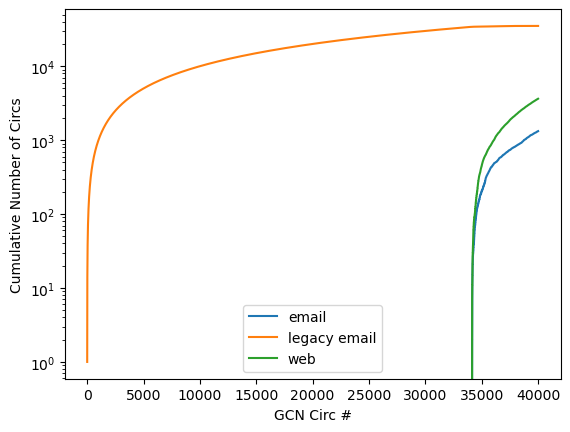

40003 40003


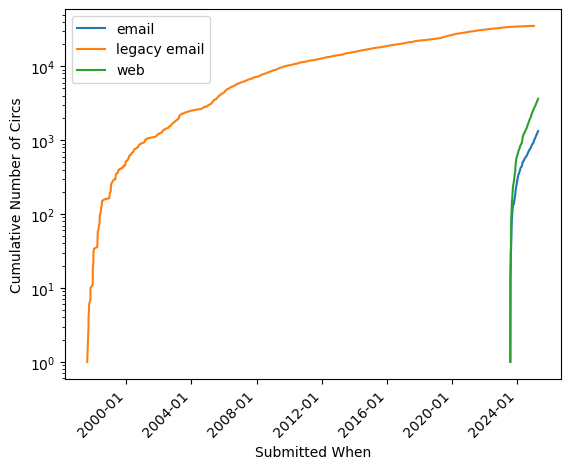

In [12]:
#print(np.array(circ)[wemail])
#print(min(circ),max(circ))
#i=np.arange(min(circ),max(circ))
#i=np.arange(0,max(circ))
#ncircs=len(i)#max(circ)-min(circ)
ncircs=len(subhow)
print(ncircs)
i=np.arange(0,ncircs)
email=np.zeros(ncircs)
legemail=np.zeros(ncircs)
web=np.zeros(ncircs)

# for c in range(ncircs):
# #    print(circ[i],c)
#     cc=c-min(circ)
#     if subhow[cc] == 'email': email[c]=1
#     if subhow[cc] == 'email-legacy': legemail[c]=1 
#     if subhow[cc] == 'web': web[c]=1

email[wemail]=1
legemail[wlegemail]=1
web[wweb]=1

plt.plot(i,np.cumsum(email),label='email')
plt.plot(i,np.cumsum(legemail),label='legacy email')
plt.plot(i,np.cumsum(web),label='web')
#plt.plot(i,np.cumsum(np.ones(len(i))),label='all circs')
plt.xlabel('GCN Circ #')
plt.ylabel('Cumulative Number of Circs')
plt.legend()
plt.yscale('log')
plt.show()
# values, base = np.histogram(circ[wemail], bins=)
# cumulative = np.cumsum(values)
# plt.plot(circ[wemail][:-1], cumulative)

#subwhendate=dates.date2num(subwhen)
#print(subwhendate)
print(len(subwhen),len(np.cumsum(email)))
plt.plot(subwhen[wemail],np.cumsum(email[wemail]),label='email')
#plt.plot(subwhen,np.cumsum(email),label='email')
plt.plot(subwhen[wlegemail],np.cumsum(legemail[wlegemail]),label='legacy email')
plt.plot(subwhen[wweb],np.cumsum(web[wweb]),label='web')
#plt.plot(i,np.cumsum(np.ones(len(i))),label='all circs')
plt.xlabel('Submitted When')
plt.ylabel('Cumulative Number of Circs')
plt.xticks(rotation=45, ha='right')
plt.yscale('log')
plt.gca().xaxis.set_major_formatter(dates.DateFormatter('%Y-%m'))
plt.legend()

## frac methods


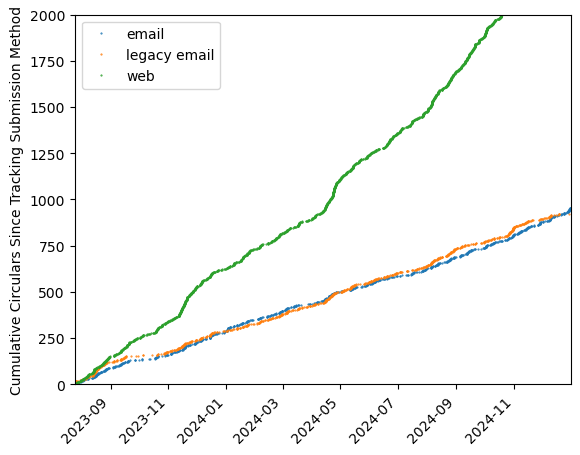

In [14]:
plt.plot(subwhen[wemail],np.cumsum(email[wemail]),label='email',marker='.',linestyle='None',markersize=1)
plt.plot(subwhen[wlegemail],np.cumsum(legemail[wlegemail])-34125,label='legacy email',marker='.',linestyle='None',markersize=1)
plt.plot(subwhen[wweb],np.cumsum(web[wweb]),label='web',marker='.',linestyle='None',markersize=1)
plt.xlim([datetime.datetime(2023,7,25),datetime.datetime(2024,12,31)])
plt.legend()
plt.ylim([00000,2000])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Cumulative Circulars Since Tracking Submission Method')
plt.gca().xaxis.set_major_formatter(dates.DateFormatter('%Y-%m'))
plt.savefig('/Users/jracusin/GCN/gitrep/gcn-notebooks/circs_since_tracking.png')

In [12]:
# for j in range(len(circ)):
#     print(circ[j],subhow[j])

In [16]:
lasthowmany=-50
legusers=np.unique(subwho[wlegemail[lasthowmany:]])
print(len(wlegemail[lasthowmany:]))
numleg=[]
for l in legusers:
    w=np.where(l==subwho[wlegemail[lasthowmany:]])[0]
    numleg.append(len(w))
    print(subwhen[wlegemail[lasthowmany:]][w][-1],int(circ[wlegemail[lasthowmany:]][w][-1]),len(w),l)

50
2024-11-30 10:48:32.785000 38395 1 Alexei Pozanenko at IKI, Moscow <grb.alex@gmail.com>
2024-12-18 16:10:18.411000 38627 1 Viraj Karambelkar at Indian Inst of Tech,Bombay <karambelkarvraj21197@gmail.com>
2024-12-18 02:36:23.881000 38609 42 Vladimir Lipunov at Moscow State U/Krylov Obs <lipunov@xray.sai.msu.ru>
2024-11-29 11:03:19.880000 38383 2 XXXX at IKI <alex@cgrsmx.iki.rssi.ru>
2025-01-03 22:37:11.658000 38814 4 Zipei Zhu at NAOC <zpzhu@nao.cas.cn>


In [17]:
import re
emails=[]
for l in legusers:
    sp=re.split('<|>',l)
    if len(sp)>1:
        emails.append(sp[1])
    else:
        emails.append(l)
uniqemails=np.unique(emails)
for e in uniqemails:
    print(e)

alex@cgrsmx.iki.rssi.ru
grb.alex@gmail.com
karambelkarvraj21197@gmail.com
lipunov@xray.sai.msu.ru
zpzhu@nao.cas.cn


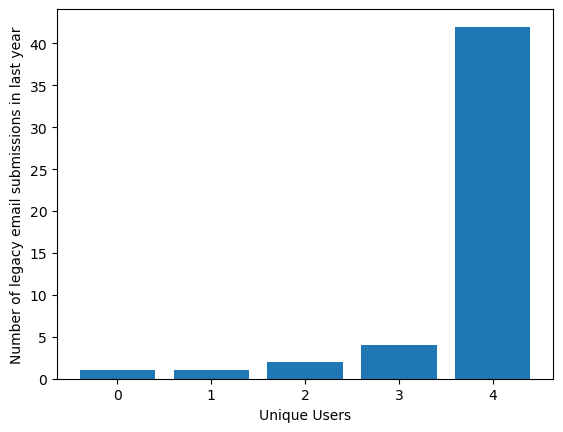

In [22]:
s=np.argsort(np.array(numleg))
l=np.arange(0,len(s))
plt.bar(l,np.array(numleg)[s])
plt.xlabel('Unique Users')
plt.ylabel('Number of legacy email submissions in last year')
plt.savefig('/Users/jracusin/GCN/gitrep/gcn-notebooks/unique_legacy_users_lastyear.png')

21


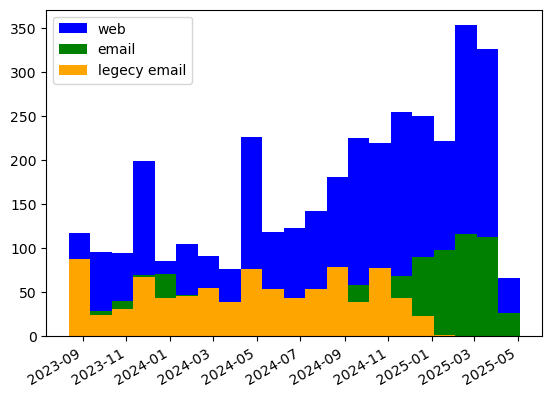

In [23]:
one_week = datetime.timedelta(days = 30)
date_list=subwhen[34263:]
start=min(date_list)
end=max(date_list)
weeks=round((end-start).days/30+0.5)
print(weeks)
#plt.hist(subwhen[34263:],bins=range(start_date,stop_date) + bin_day, bin_day)
week = [] 
for i in range(weeks+1):  
    week.append(start + (i)*one_week)
#print(week)

numweek = dates.date2num(week)

#h0=plt.hist(subwhen, bins = numweek, ec="k",stacked=True)
h3=plt.hist(subwhen[wweb], bins = numweek, ec="k",label='web',stacked=True,color='blue')
h1=plt.hist(subwhen[wemail], bins = numweek, ec="k",label='email',stacked=True,color='green')
h2=plt.hist(subwhen[wlegemail], bins = numweek, ec="k",label='legecy email',stacked=True,color='orange')
# print(h1[2])
# print(h2[2])
# print(h3[2])
plt.legend()
plt.gcf().autofmt_xdate()
plt.show()

In [24]:
plt.plot(h0[1][:-1],h1[0]/h0[0],label='email')
plt.plot(h0[1][:-1],h2[0]/h0[0],label='legacy email')
plt.plot(h0[1][:-1],h3[0]/h0[0],label='web')
plt.legend()
plt.gca().xaxis.set_major_formatter(dates.DateFormatter('%Y-%m'))
plt.ylabel('Fraction of Submission Method Usage')
plt.gcf().autofmt_xdate()
plt.savefig('fraction_submission_method.png')
plt.show()

NameError: name 'h0' is not defined

In [48]:
noevid=np.where(evid=='None')[0]
print(len(noevid))
for i in range(len(noevid)):
    print(i,int(circ[noevid[i]]),evid[noevid[i]],subject[noevid[i]])

3277
0 -1 None Possible new SGR from US Naval Observatory
1 -2 None RXTE Observations of SGR 1814-13
2 0 None IRAS 18119-1342 and the possible new SGR
3 54 None GRByymmdd, Announcement of automation
4 66 None SAX J0840.7+2248 Optical Observations
5 68 None IPN web site of GRBs
6 76 None BATSE on-board GRB trigger change
7 93 None BATSE on-board GRB trigger change
8 94 None SGR1900+14
9 95 None SGR1900+14
10 97 None SGR 1900+14
11 107 None Discovery of a new SGR source, SGR1627-41
12 110 None SGR 1627-41
13 111 None SGR1627-41, BeppoSAX-GRBM detections
14 113 None Reduced error box of SGR 1627-41
15 115 None SGR1627-41, Refined IPN annulus location
16 116 None SGR1627-41, RXTE/ASM observations
17 120 None SGR1900+14 field optical observations
18 121 None Radio observations of SGRs
19 122 None SGR1627-41
20 153 None SGR1900+14, BeppoSAX-GRBM observations
21 264 None BATSE Flight Anomaly
22 265 None BATSE Resumes Normal Operations
23 333 None BeppoSAX: A new fast X-ray transient
24 334 No

In [71]:
searchkey='S230518h'
s=np.where(np.char.find(subject,searchkey)!= -1)[0]
for i in range(len(s)):
    print(i,int(circ[s[i]]),',',evid[s[i]],',',subject[s[i]])

0 33813 , LIGO/Virgo/KAGRA S230518h , LIGO/Virgo/KAGRA S230518h: Identification of a GW compact binary merger candidate
1 33814 , LIGO/Virgo S230518h , LIGO/Virgo S230518h: Upper limits from IceCube neutrino search
2 33815 , LIGO/Virgo S230518h , LIGO/Virgo S230518h: No counterpart candidates in INTEGRAL SPI-ACS prompt observation
3 33816 , LIGO/Virgo/KAGRA S230518h , LIGO/Virgo/KAGRA S230518h: Updated Sky localization and EM Bright Classification
4 33817 , LIGO/Virgo S230518h , LIGO/Virgo S230518h: Global MASTER-Net observations report
5 33818 , LIGO/Virgo/KAGRA S230518h , LIGO/Virgo/KAGRA S230518h: Upper limits from Fermi-GBM Observations
6 33819 , LIGO/Virgo/KAGRA S230518h , LIGO/Virgo/KAGRA S230518h: AstroSat CZTI non-detection and upper limits
7 33820 , LIGO/Virgo/Kagra S230518h , LIGO/Virgo/Kagra S230518h: NED Galaxies in the Localization Volume
8 33823 , LIGO/Virgo/KAGRA S230518h , LIGO/Virgo/KAGRA S230518h: Coverage and upper limits from MAXI/GSC observations
9 33824 , LIGO/Vir

In [20]:
## Find missing bibcodes
w=np.where((bibcode == 'None') & (circ < 41591))[0]
print(len(w))
print('Bibcode','Circ#','URL')
for i in range(len(w)):
    print(bibcode[w[i]],int(circ[w[i]]),'https://gcn.nasa.gov/circulars/'+str(int(circ[w[i]])))

439
Bibcode Circ# URL
None -4 https://gcn.nasa.gov/circulars/-4
None -3 https://gcn.nasa.gov/circulars/-3
None -1 https://gcn.nasa.gov/circulars/-1
None -2 https://gcn.nasa.gov/circulars/-2
None 0 https://gcn.nasa.gov/circulars/0
None 1 https://gcn.nasa.gov/circulars/1
None 5 https://gcn.nasa.gov/circulars/5
None 2 https://gcn.nasa.gov/circulars/2
None 3 https://gcn.nasa.gov/circulars/3
None 4 https://gcn.nasa.gov/circulars/4
None 6 https://gcn.nasa.gov/circulars/6
None 9 https://gcn.nasa.gov/circulars/9
None 7 https://gcn.nasa.gov/circulars/7
None 8 https://gcn.nasa.gov/circulars/8
None 13 https://gcn.nasa.gov/circulars/13
None 12 https://gcn.nasa.gov/circulars/12
None 11 https://gcn.nasa.gov/circulars/11
None 10 https://gcn.nasa.gov/circulars/10
None 14 https://gcn.nasa.gov/circulars/14
None 15 https://gcn.nasa.gov/circulars/15
None 16 https://gcn.nasa.gov/circulars/16
None 19 https://gcn.nasa.gov/circulars/19
None 18 https://gcn.nasa.gov/circulars/18
None 17 https://gcn.nasa.gov/cir